In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300


In [3]:
gcn4_seq_df =pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/Table_S7_Full_length_ortholog_dataframe.csv")
gcn4_seq_df = gcn4_seq_df[["SpeciesName", "Seq", "Length"]]
gcn4_seq_df

,SpeciesName,Seq,Length
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943
...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251


In [4]:
gcn4_speeds = pd.read_csv("../../../output/GCN4_pipeline/speed/exponential_fit.csv", index_col = 0)[["ADseq", "A*k"]]
gcn4_speeds

,ADseq,A*k
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,0.416598
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.103366
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,0.321955
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,0.317768
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,0.392171
...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,0.477552
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0.542856
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,0.336945
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,0.094484


In [5]:
def get_all_starts(full_seq, tile):
    starts = []
    start = 0
    while True:
        pos = full_seq.find(tile, start)
        if pos == -1:
            break
        starts.append(pos)
        start = pos + 1
    return starts

def get_coverage_stats(full_seq, speeds_df):
    mask = speeds_df['ADseq'].apply(lambda tile: tile in full_seq)
    matching = speeds_df[mask]
    
    if matching.empty:
        return pd.Series({
            'max_speed': None,
            'mean_speed': None,
            'median_speed': None,
            'top3_mean_speed': None,
            'speed_std': None,
            'tile_count': 0,
            'seq_length': len(full_seq),
            'coverage_fraction': 0.0
        })
    
    covered = set()
    for tile in matching['ADseq']:
        for start in get_all_starts(full_seq, tile):
            covered.update(range(start, start + len(tile)))
    
    speeds = matching['A*k']
    
    return pd.Series({
        'max_speed':       speeds.max(),
        'mean_speed':      speeds.mean(),
        'median_speed':    speeds.median(),
        'top3_mean_speed': speeds.nlargest(3).mean(),
        'speed_std':       speeds.std(),
        'tile_count':      len(matching),
        'seq_length':      len(full_seq),
        'coverage_fraction': len(covered) / len(full_seq)
    })


gcn4_seq_df = gcn4_seq_df.join(
    gcn4_seq_df['Seq'].apply(lambda seq: get_coverage_stats(seq, gcn4_speeds))
)

In [6]:
gcn4_seq_df

,SpeciesName,Seq,Length,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,seq_length,coverage_fraction
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928,0.859456,0.275723,0.227009,0.827256,0.187403,83.0,2928.0,0.396516
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455,0.859456,0.354060,0.296529,0.827256,0.200397,46.0,455.0,0.498901
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222,0.859456,0.368919,0.317147,0.827256,0.208811,40.0,222.0,0.572072
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243,0.859456,0.364886,0.317724,0.827256,0.198141,45.0,243.0,0.617284
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943,0.859456,0.274313,0.220883,0.827256,0.187924,83.0,2943.0,0.394495
...,...,...,...,...,...,...,...,...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242,1.055879,0.443051,0.405916,0.942155,0.268572,18.0,242.0,0.586777
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260,0.994908,0.377019,0.377383,0.808934,0.228984,21.0,260.0,0.634615
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239,0.533748,0.356870,0.303200,0.501126,0.123830,8.0,239.0,0.543933
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251,0.818431,0.408351,0.404747,0.695746,0.195821,15.0,251.0,0.617530


In [7]:
gcn4_seq_df_with_max_speeds = gcn4_seq_df.dropna()
gcn4_seq_df_with_max_speeds

,SpeciesName,Seq,Length,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,seq_length,coverage_fraction
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928,0.859456,0.275723,0.227009,0.827256,0.187403,83.0,2928.0,0.396516
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455,0.859456,0.354060,0.296529,0.827256,0.200397,46.0,455.0,0.498901
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222,0.859456,0.368919,0.317147,0.827256,0.208811,40.0,222.0,0.572072
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243,0.859456,0.364886,0.317724,0.827256,0.198141,45.0,243.0,0.617284
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943,0.859456,0.274313,0.220883,0.827256,0.187924,83.0,2943.0,0.394495
...,...,...,...,...,...,...,...,...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242,1.055879,0.443051,0.405916,0.942155,0.268572,18.0,242.0,0.586777
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260,0.994908,0.377019,0.377383,0.808934,0.228984,21.0,260.0,0.634615
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239,0.533748,0.356870,0.303200,0.501126,0.123830,8.0,239.0,0.543933
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251,0.818431,0.408351,0.404747,0.695746,0.195821,15.0,251.0,0.617530


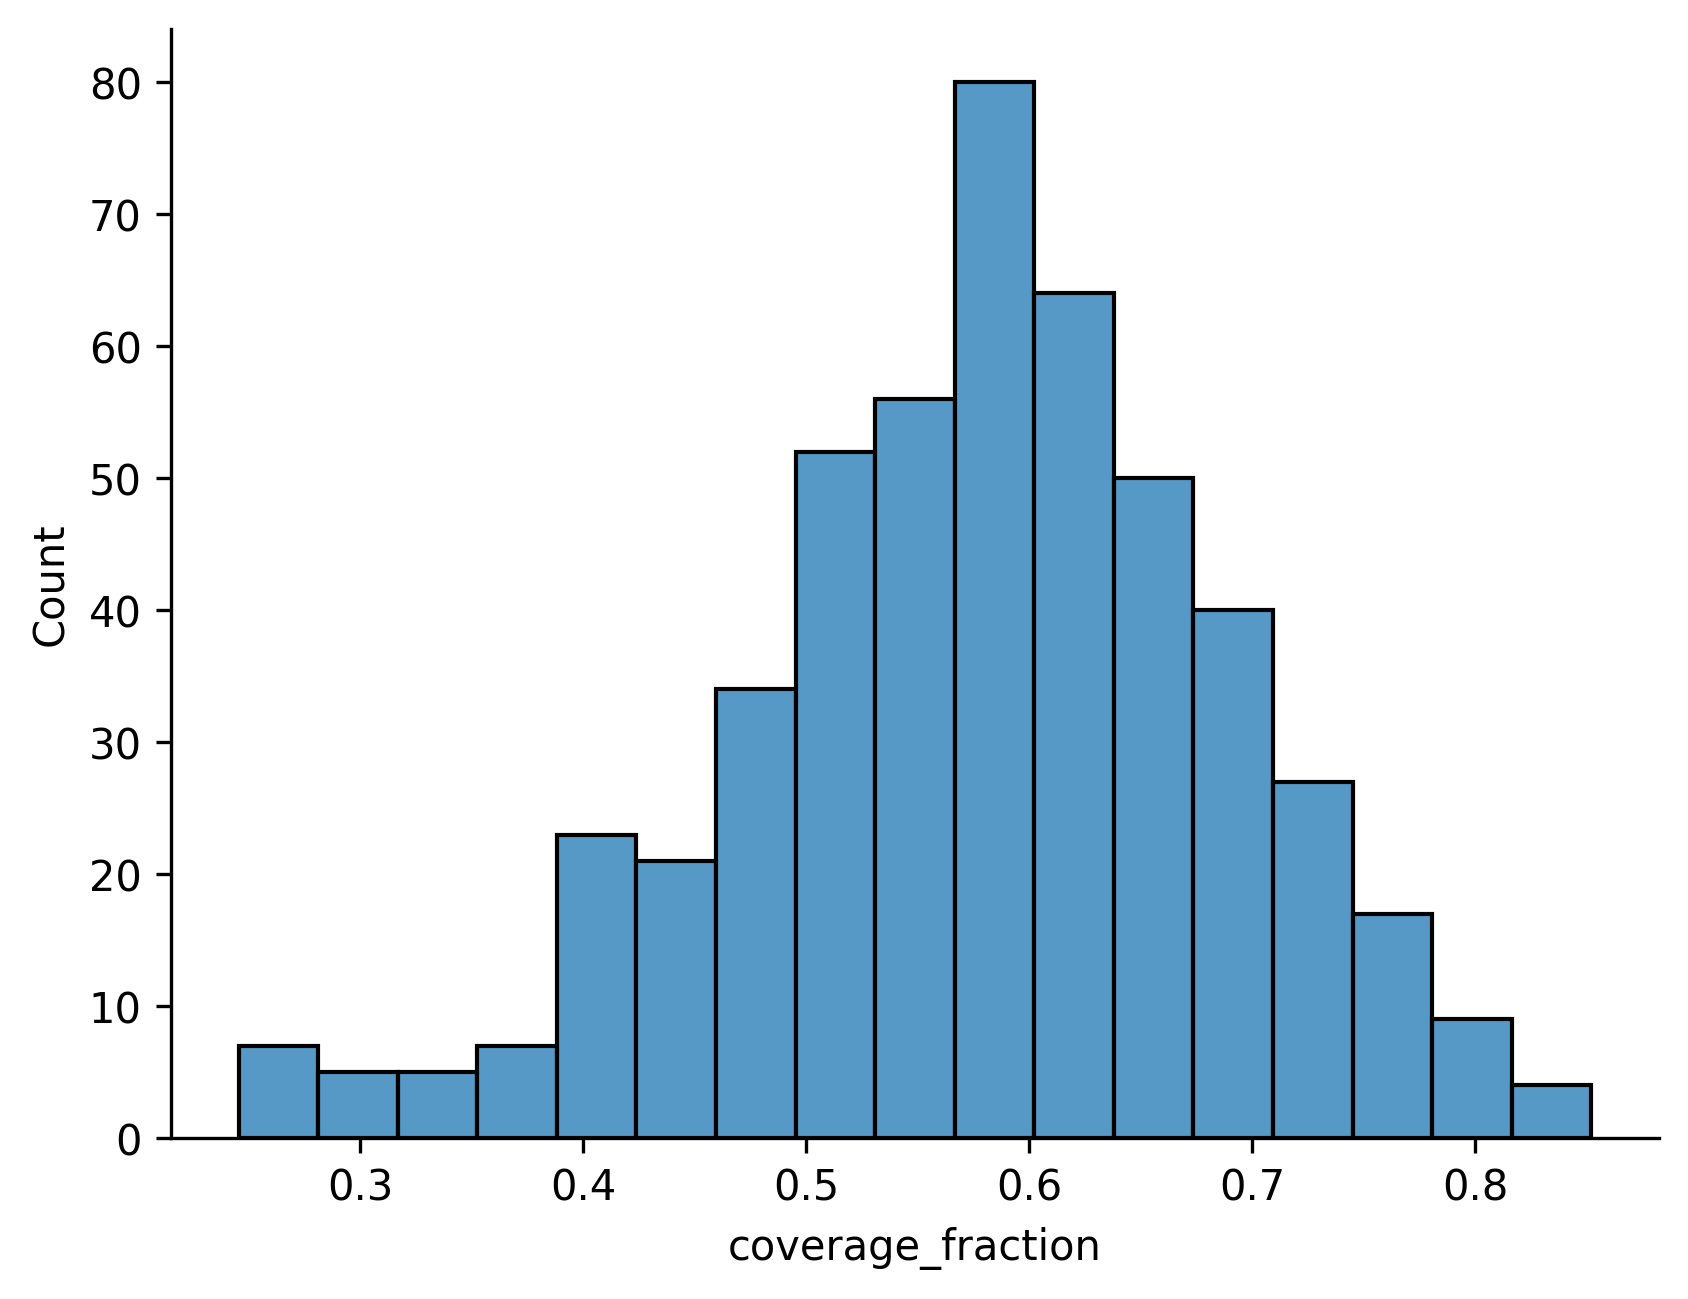

In [8]:
sns.histplot(gcn4_seq_df_with_max_speeds["coverage_fraction"])
sns.despine()

In [9]:
gcn4_seq_df_with_max_speeds_suffic_cov = gcn4_seq_df_with_max_speeds[gcn4_seq_df_with_max_speeds["coverage_fraction"] >= 0.3]
gcn4_seq_df_with_max_speeds_suffic_cov

,SpeciesName,Seq,Length,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,seq_length,coverage_fraction
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928,0.859456,0.275723,0.227009,0.827256,0.187403,83.0,2928.0,0.396516
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455,0.859456,0.354060,0.296529,0.827256,0.200397,46.0,455.0,0.498901
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222,0.859456,0.368919,0.317147,0.827256,0.208811,40.0,222.0,0.572072
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243,0.859456,0.364886,0.317724,0.827256,0.198141,45.0,243.0,0.617284
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943,0.859456,0.274313,0.220883,0.827256,0.187924,83.0,2943.0,0.394495
...,...,...,...,...,...,...,...,...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242,1.055879,0.443051,0.405916,0.942155,0.268572,18.0,242.0,0.586777
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260,0.994908,0.377019,0.377383,0.808934,0.228984,21.0,260.0,0.634615
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239,0.533748,0.356870,0.303200,0.501126,0.123830,8.0,239.0,0.543933
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251,0.818431,0.408351,0.404747,0.695746,0.195821,15.0,251.0,0.617530


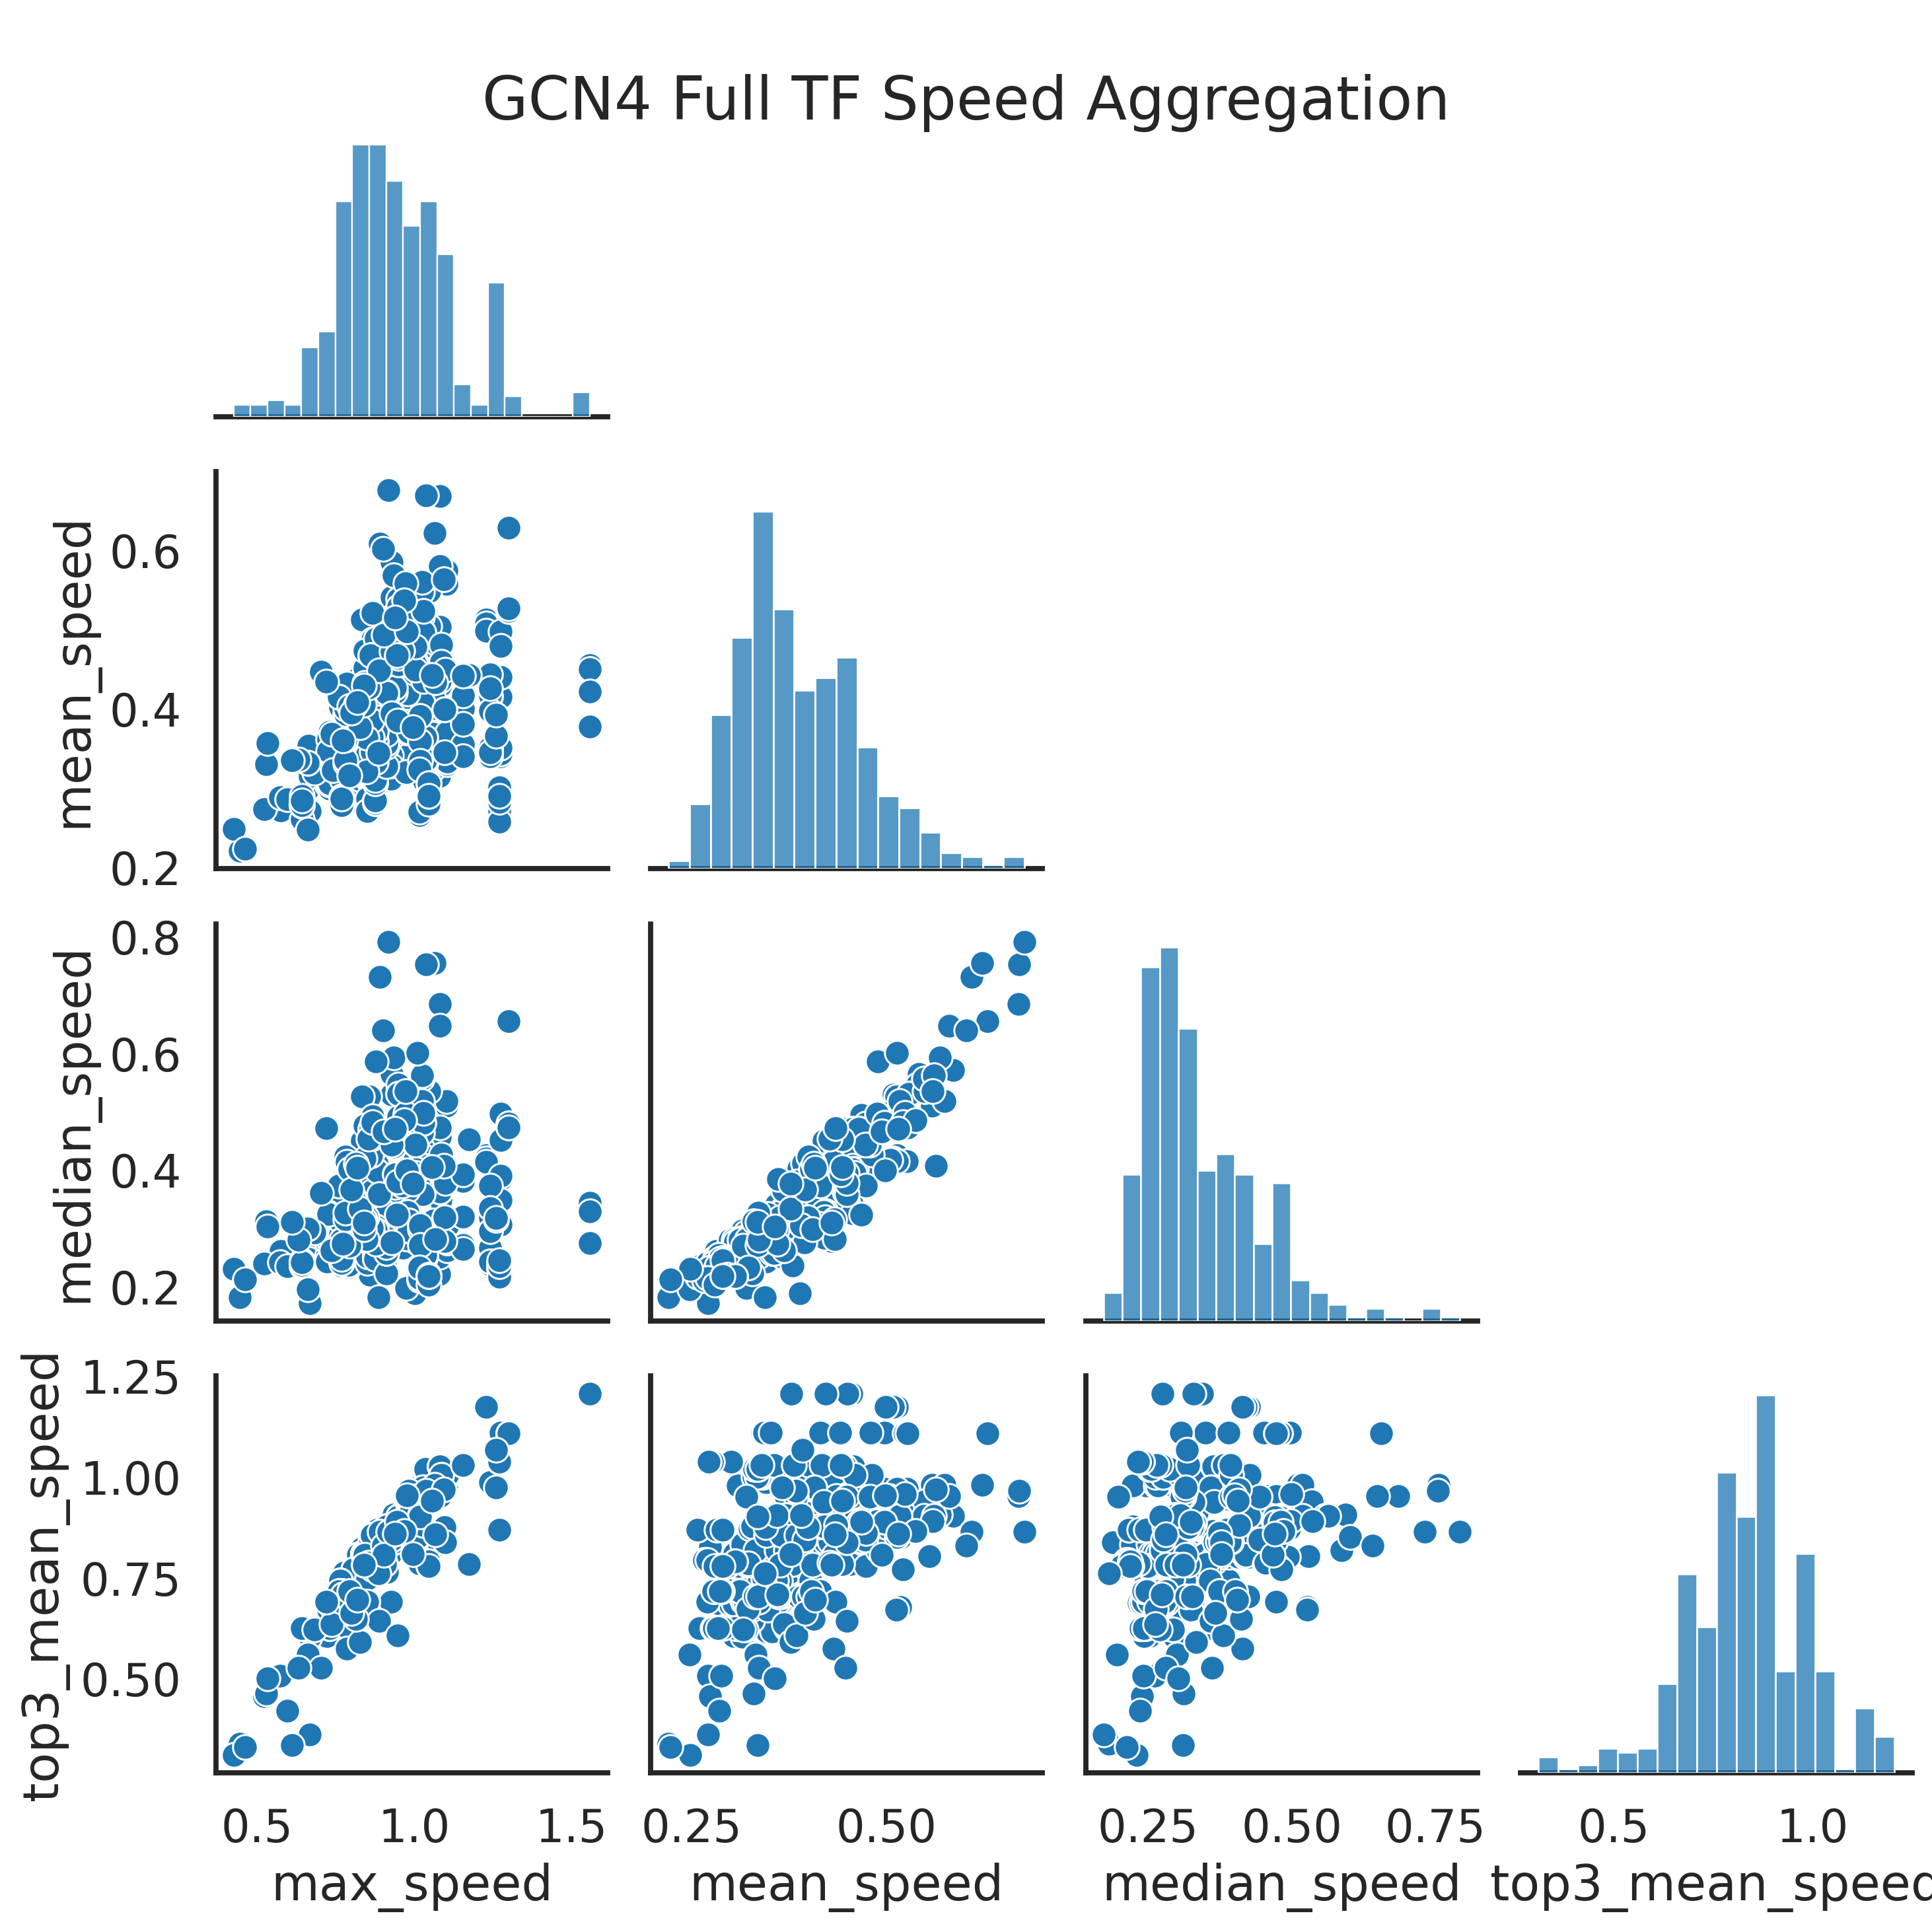

In [10]:
sns.set_context('talk')
sns.set_style('white')
sns.pairplot(gcn4_seq_df_with_max_speeds_suffic_cov[["max_speed", "mean_speed", "median_speed", "top3_mean_speed"]],
            corner=True)
plt.suptitle("GCN4 Full TF Speed Aggregation", y = 0.95)
plt.show()